This notebook trains an exploratory XGBoost classification model to evaluate feature importance and baseline performance using metrics like AUC, precision, and recall

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_parquet('data/v80_new_features/final_model_data_the_rescaled.parquet')

In [3]:
df['mamba_preds'] = np.load("models/best/mamba_var_lim_1_pred_probas.npy")

In [4]:
df.columns

Index(['Epoch_time', 'Bx', 'By', 'Bz', 'Bx_lag_1', 'Bx_lag_2', 'By_lag_1',
       'By_lag_2', 'Bz_lag_1', 'Bz_lag_2', 'Bx_conditional_vol',
       'By_conditional_vol', 'Bz_conditional_vol', 'LIM_scale_2_log',
       'LIM_scale_4_log', 'LIM_scale_8_log', 'LIM_scale_16_log',
       'LIM_scale_32_log', 'LIM_scale_64_log', 'Event_label_80',
       'Event_label_100', 'mamba_preds'],
      dtype='object')

In [5]:
X = df[['Bx', 'By', 'Bz', 'Bx_lag_1', 'Bx_lag_2', 'By_lag_1',
        'By_lag_2', 'Bz_lag_1', 'Bz_lag_2', 'Bx_conditional_vol',
        'By_conditional_vol', 'Bz_conditional_vol', 'LIM_scale_2_log',
       'LIM_scale_4_log', 'LIM_scale_8_log', 'LIM_scale_16_log',
       'LIM_scale_32_log', 'LIM_scale_64_log']].values

y = df['mamba_preds'].values

In [6]:
del df

In [7]:
split = int(len(X) * 0.75)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

XGBoost is a machine learning library that implements gradient boosted decision trees for classification

In [8]:
clf = XGBRegressor(
    n_estimators=800,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [9]:
print(f"R2: {r2_score(y_test, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"Correlation: {np.corrcoef(y_test, y_pred)[0, 1]}")

R2: 0.6728321313858032
MAE: 0.1480739861726761
RMSE: 0.20173020660877228
Correlation: 0.8203410446902026


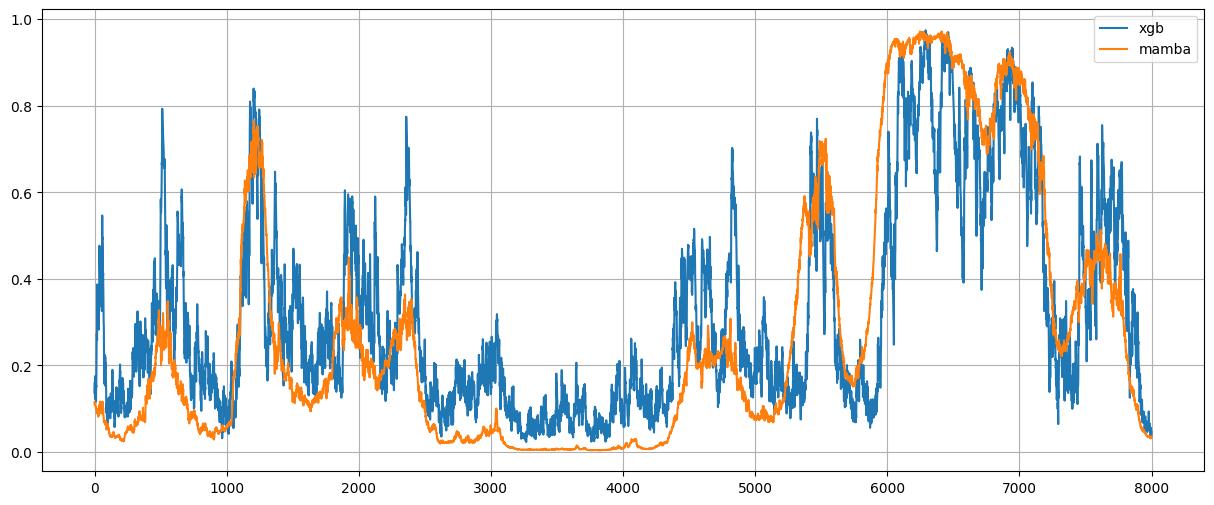

In [10]:
start_idx = 4000 - 4000
end_idx = 4000 + 4000

plt.figure(figsize=(15, 6))
plt.plot(y_pred[start_idx:end_idx], label='xgb')
plt.plot(y_test[start_idx:end_idx], label='mamba')
plt.legend()
plt.grid()
plt.show()